In [1]:
# ─────────────────────────────────────────────
# Install dependencies
# ─────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "-q", "segmentation-models-pytorch", "xgboost"], check=True)

import os
import cv2
import gc
import json
import copy
import random
import shutil
import warnings
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_V2_S_Weights
import segmentation_models_pytorch as smp
import xgboost as xgb

warnings.filterwarnings("ignore")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00


In [4]:
# ─────────────────────────────────────────────
# Reproducibility & Device
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# ─────────────────────────────────────────────
# Global Config  ← all tunables in one place
# ─────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE_SEG = 8
BATCH_SIZE_CLS = 16
NUM_WORKERS    = 2
SEG_EPOCHS     = 5
CLS_EPOCHS     = 10
PATIENCE       = 7
TARGET_COUNT   = 1000


# ─────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────
brain_tumor_paths = {
    "Normal":     "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (16)/Data/Normal",
    "Glioma":     "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (16)/Data/Tumor/glioma_tumor",
    "Meningioma": "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (16)/Data/Tumor/meningioma_tumor",
    "Pituitary":  "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (16)/Data/Tumor/pituitary_tumor",
}
alz_paths = {
    "MildDemented":     "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (17)/AugmentedAlzheimerDataset/MildDemented",
    "ModerateDemented": "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (17)/AugmentedAlzheimerDataset/ModerateDemented",
    "NonDemented":      "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (17)/AugmentedAlzheimerDataset/NonDemented",
    "VeryMildDemented": "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (17)/AugmentedAlzheimerDataset/VeryMildDemented",
}
ms_paths = {
    "Control_Axial":    "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (18)/MS/Control Axial_crop",
    "Control_Saggital": "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (18)/MS/Control Saggital_crop",
    "MS_Axial":         "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (18)/MS/MS Axial_crop",
    "MS_Saggital":      "/kaggle/input/datasets/rahulpudi/multibraindisease/archive (18)/MS/MS Saggital_crop",
}

Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [5]:
# ─────────────────────────────────────────────
# Dataset Balancing
# ─────────────────────────────────────────────
IMG_EXTS      = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
combined_root = "/kaggle/working/balanced_dataset"
os.makedirs(combined_root, exist_ok=True)

def balance_and_copy(src_dict):
    for label, src_path in src_dict.items():
        dst_path = os.path.join(combined_root, label)
        os.makedirs(dst_path, exist_ok=True)
        files = [f for f in os.listdir(src_path) if f.lower().endswith(IMG_EXTS)]
        if not files:
            print(f"[WARNING] No images in {label} at {src_path}")
            continue
        random.shuffle(files)
        if len(files) >= TARGET_COUNT:
            selected = files[:TARGET_COUNT]
        else:
            extra    = np.random.choice(files, size=TARGET_COUNT - len(files), replace=True)
            selected = list(files) + list(extra)
        for i, f in enumerate(selected):
            shutil.copy(os.path.join(src_path, f),
                        os.path.join(dst_path, f"{i}_{f}"))
        print(f"  {label}: {len(selected)} images")

print("Balancing datasets...")
balance_and_copy(brain_tumor_paths)
balance_and_copy(alz_paths)
balance_and_copy(ms_paths)
print("Dataset balanced.\n")


# ─────────────────────────────────────────────
# DataFrame & Splits
# ─────────────────────────────────────────────
def build_dataframe(root_dir):
    rows = []
    for cls in sorted(os.listdir(root_dir)):
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(IMG_EXTS):
                rows.append({"filepath": os.path.join(cls_dir, fname), "label_name": cls})
    return pd.DataFrame(rows)

df          = build_dataframe(combined_root)
class_names = sorted(df["label_name"].unique())
label2idx   = {label: i for i, label in enumerate(class_names)}
idx2label   = {i: label for label, i in label2idx.items()}
df["label"] = df["label_name"].map(label2idx)
num_classes = len(class_names)

print(f"Total images : {len(df)}")
print(df["label_name"].value_counts(), "\n")

train_df, temp_df = train_test_split(df,      test_size=0.30, stratify=df["label"],      random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}\n")





Balancing datasets...
  Normal: 1000 images
  Glioma: 1000 images
  Meningioma: 1000 images
  Pituitary: 1000 images
  MildDemented: 1000 images
  ModerateDemented: 1000 images
  NonDemented: 1000 images
  VeryMildDemented: 1000 images
  Control_Axial: 1000 images
  Control_Saggital: 1000 images
  MS_Axial: 1000 images
  MS_Saggital: 1000 images
Dataset balanced.

Total images : 12000
label_name
Control_Axial       1000
Control_Saggital    1000
Glioma              1000
MS_Axial            1000
MS_Saggital         1000
Meningioma          1000
MildDemented        1000
ModerateDemented    1000
NonDemented         1000
Normal              1000
Pituitary           1000
VeryMildDemented    1000
Name: count, dtype: int64 

Train: 8400  Val: 1800  Test: 1800



In [6]:
# ─────────────────────────────────────────────
# Image helpers
# ─────────────────────────────────────────────
def read_rgb_image(path, size=IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Cannot read: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def create_pseudo_mask(rgb_img):
    """
    Otsu-threshold pseudo-mask — used ONLY as supervision signal
    while training the UNet++.  Not used during classification.
    """
    gray = cv2.GaussianBlur(cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY), (5, 5), 0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(mask > 0) > 0.6:
        mask = 255 - mask
    kernel = np.ones((5, 5), np.uint8)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    n_lbl, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_lbl > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.where(lbl == largest, 255, 0).astype(np.uint8)
    return (mask > 0).astype(np.float32)


# ─────────────────────────────────────────────
# UNet++ inference helper
# CPU copy kept for DataLoader worker safety —
# CUDA cannot be used in forked subprocesses.
# ─────────────────────────────────────────────
seg_model_cpu = None   # populated after UNet++ training

@torch.no_grad()
def unetpp_predict_mask(seg_model_cpu, rgb_img_uint8, threshold=0.5):
    """
    CPU-only forward pass — safe to call from DataLoader worker processes.
    Returns a (H, W) float32 binary mask {0, 1}.
    """
    seg_model_cpu.eval()
    img_f  = rgb_img_uint8.astype(np.float32) / 255.0
    tensor = torch.tensor(img_f).permute(2, 0, 1).unsqueeze(0)   # stays on CPU
    logit  = seg_model_cpu(tensor)                                 # CPU forward
    return (torch.sigmoid(logit).squeeze().numpy() > threshold).astype(np.float32)




In [7]:
# ─────────────────────────────────────────────
# Datasets
# ─────────────────────────────────────────────
class SegmentationDataset(Dataset):
    """Feeds the UNet++: raw image → pseudo-mask supervision."""
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img  = read_rgb_image(self.df.loc[idx, "filepath"])
        mask = create_pseudo_mask(img)
        img  = img.astype(np.float32) / 255.0
        return (torch.tensor(img).permute(2, 0, 1),
                torch.tensor(mask).unsqueeze(0))


_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])

train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class ClassificationDataset(Dataset):
    """
    Full pipeline per sample:
      raw image ──▶ UNet++ (CPU) mask ──▶ mask × image ──▶ augment ──▶ normalise

    UNet++ runs on CPU so this class is safe to use with num_workers > 0.
    CUDA cannot be used inside forked DataLoader worker processes.
    """
    def __init__(self, dataframe, seg_model_cpu, augment=False):
        self.df            = dataframe.reset_index(drop=True)
        self.seg_model_cpu = seg_model_cpu   # CPU copy, frozen, eval-mode
        self.augment       = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.loc[idx]
        img_u8 = read_rgb_image(row["filepath"])
        mask   = unetpp_predict_mask(self.seg_model_cpu, img_u8)          # CPU-safe
        img_f  = img_u8.astype(np.float32) / 255.0
        img_f  = img_f * np.expand_dims(mask, axis=-1)                    # zero out background
        img_t  = torch.tensor(img_f).permute(2, 0, 1)
        if self.augment:
            img_t = train_aug(img_t)
        img_t = _normalize(img_t)
        return img_t, torch.tensor(int(row["label"]), dtype=torch.long)




In [8]:
# ─────────────────────────────────────────────
# Segmentation DataLoaders
# ─────────────────────────────────────────────
seg_train_loader = DataLoader(
    SegmentationDataset(train_df),
    batch_size=BATCH_SIZE_SEG, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
seg_val_loader = DataLoader(
    SegmentationDataset(val_df),
    batch_size=BATCH_SIZE_SEG, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)


# ─────────────────────────────────────────────
# Segmentation Model — UNet++ with EfficientNet-B2 encoder
#
# smp.UnetPlusPlus adds dense skip connections between encoder
# and decoder stages, improving boundary detail over plain UNet.
# EfficientNet-B2 encoder kept for VRAM efficiency on P100.
# ─────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()

seg_model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_attention_type="scse",   # channel + spatial squeeze-excite in decoder
).to(device)

# Enable gradient checkpointing on the encoder to reduce VRAM usage
if hasattr(seg_model.encoder, "set_grad_checkpointing"):
    seg_model.encoder.set_grad_checkpointing(True)

dice_loss_fn  = smp.losses.DiceLoss(mode="binary")
bce_loss_fn   = nn.BCEWithLogitsLoss()
seg_optimizer = optim.AdamW(seg_model.parameters(), lr=1e-4, weight_decay=1e-5)
seg_scheduler = optim.lr_scheduler.OneCycleLR(
    seg_optimizer,
    max_lr=3e-4,
    steps_per_epoch=len(seg_train_loader),
    epochs=SEG_EPOCHS,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10,
    final_div_factor=100,
)
seg_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"GPU memory after seg model init: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB allocated / "
      f"{torch.cuda.memory_reserved() / 1e9:.2f} GB reserved")




config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

GPU memory after seg model init: 0.04 GB allocated / 0.05 GB reserved


In [9]:
# ─────────────────────────────────────────────
# Segmentation train / val helpers
# ─────────────────────────────────────────────
def dice_score_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

def train_seg_one_epoch(model, loader, optimizer, scaler, scheduler):
    model.train()
    run_loss = run_dice = 0.0
    for imgs, masks in tqdm(loader, leave=False, desc="  seg-train"):
        imgs  = imgs.to(device,  non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = 0.7 * dice_loss_fn(logits, masks) + 0.3 * bce_loss_fn(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        run_loss += loss.item() * imgs.size(0)
        run_dice += dice_score_from_logits(logits, masks) * imgs.size(0)
    n = len(loader.dataset)
    return run_loss / n, run_dice / n

@torch.no_grad()
def validate_seg_one_epoch(model, loader):
    model.eval()
    run_loss = run_dice = 0.0
    for imgs, masks in tqdm(loader, leave=False, desc="  seg-val"):
        imgs  = imgs.to(device,  non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = 0.7 * dice_loss_fn(logits, masks) + 0.3 * bce_loss_fn(logits, masks)
        run_loss += loss.item() * imgs.size(0)
        run_dice += dice_score_from_logits(logits, masks) * imgs.size(0)
    n = len(loader.dataset)
    return run_loss / n, run_dice / n


# ─────────────────────────────────────────────
# ── SEGMENTATION TRAINING LOOP ──
# ─────────────────────────────────────────────
best_seg_val_loss = float("inf")
seg_history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}

for epoch in range(SEG_EPOCHS):
    print(f"\n[Segmentation — UNet++] Epoch {epoch+1}/{SEG_EPOCHS}")
    tr_loss, tr_dice = train_seg_one_epoch(
        seg_model, seg_train_loader, seg_optimizer, seg_scaler, seg_scheduler)
    vl_loss, vl_dice = validate_seg_one_epoch(seg_model, seg_val_loader)

    seg_history["train_loss"].append(tr_loss)
    seg_history["val_loss"].append(vl_loss)
    seg_history["train_dice"].append(tr_dice)
    seg_history["val_dice"].append(vl_dice)

    print(f"  Train  Loss: {tr_loss:.4f}  Dice: {tr_dice:.4f}")
    print(f"  Val    Loss: {vl_loss:.4f}  Dice: {vl_dice:.4f}")

    if vl_loss < best_seg_val_loss:
        best_seg_val_loss = vl_loss
        torch.save(seg_model.state_dict(), "/kaggle/working/unetpp_best.pth")
        print("  ✓ Saved best UNet++")

    gc.collect()
    torch.cuda.empty_cache()

print("\nSegmentation training complete.")





[Segmentation — UNet++] Epoch 1/5


  Train  Loss: 0.1765  Dice: 0.8604
  Val    Loss: 0.1021  Dice: 0.9058
  ✓ Saved best UNet++

[Segmentation — UNet++] Epoch 2/5


  Train  Loss: 0.0940  Dice: 0.9037
  Val    Loss: 0.0796  Dice: 0.9215
  ✓ Saved best UNet++

[Segmentation — UNet++] Epoch 3/5


  Train  Loss: 0.0740  Dice: 0.9227
  Val    Loss: 0.0704  Dice: 0.9240
  ✓ Saved best UNet++

[Segmentation — UNet++] Epoch 4/5


  Train  Loss: 0.0574  Dice: 0.9359
  Val    Loss: 0.0708  Dice: 0.9246

[Segmentation — UNet++] Epoch 5/5


  Train  Loss: 0.0477  Dice: 0.9431
  Val    Loss: 0.0635  Dice: 0.9299
  ✓ Saved best UNet++

Segmentation training complete.


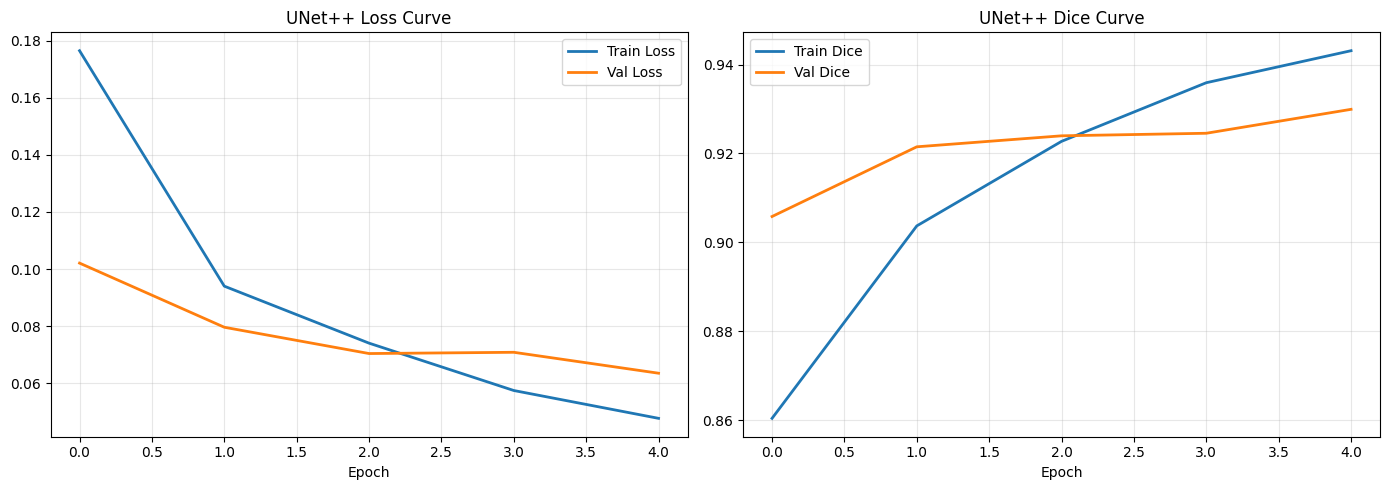

Best UNet++ loaded.
  GPU copy  → batch inference
  CPU copy  → DataLoader worker mask generation

GPU memory after freezing UNet++: 0.17 GB allocated / 0.31 GB reserved


In [10]:
# ─────────────────────────────────────────────
# Segmentation curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(seg_history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(seg_history["val_loss"],   label="Val Loss",   linewidth=2)
axes[0].set_title("UNet++ Loss Curve"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(seg_history["train_dice"], label="Train Dice", linewidth=2)
axes[1].plot(seg_history["val_dice"],   label="Val Dice",   linewidth=2)
axes[1].set_title("UNet++ Dice Curve"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/segmentation_curves.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────
# Load best UNet++ weights
# Two copies:
#   seg_model      — GPU, used for batch inference post-training
#   seg_model_cpu  — CPU, used inside DataLoader workers (CUDA-unsafe context)
# ─────────────────────────────────────────────
seg_model.load_state_dict(torch.load("/kaggle/working/unetpp_best.pth", map_location=device))
seg_model.eval()
for p in seg_model.parameters():
    p.requires_grad_(False)

seg_model_cpu = copy.deepcopy(seg_model).cpu()
seg_model_cpu.eval()
for p in seg_model_cpu.parameters():
    p.requires_grad_(False)

gc.collect()
torch.cuda.empty_cache()
print("Best UNet++ loaded.")
print("  GPU copy  → batch inference")
print("  CPU copy  → DataLoader worker mask generation\n")
print(f"GPU memory after freezing UNet++: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB allocated / "
      f"{torch.cuda.memory_reserved() / 1e9:.2f} GB reserved")


# ─────────────────────────────────────────────
# Classification DataLoaders
# ─────────────────────────────────────────────
cls_train_loader = DataLoader(
    ClassificationDataset(train_df, seg_model_cpu=seg_model_cpu, augment=True),
    batch_size=BATCH_SIZE_CLS, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
cls_val_loader = DataLoader(
    ClassificationDataset(val_df, seg_model_cpu=seg_model_cpu, augment=False),
    batch_size=BATCH_SIZE_CLS, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
cls_test_loader = DataLoader(
    ClassificationDataset(test_df, seg_model_cpu=seg_model_cpu, augment=False),
    batch_size=BATCH_SIZE_CLS, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)




In [11]:
# ─────────────────────────────────────────────
# Classification Model — EfficientNetV2-S
#
# EfficientNetV2-S uses Fused-MBConv blocks in early stages for
# faster training and better accuracy vs EfficientNetV1 / DenseNet201.
# The classifier head outputs num_classes logits.
# Feature dimension: 1280-d (penultimate global-avg-pool layer).
# ─────────────────────────────────────────────
effv2_model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)

# Replace the classifier head: (Dropout → Linear(num_classes))
in_features = effv2_model.classifier[1].in_features
effv2_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features, num_classes),
)
effv2_model = effv2_model.to(device)

cls_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

# Differential LR: backbone 10× smaller than head
backbone_params = [p for n, p in effv2_model.named_parameters() if "classifier" not in n]
head_params     = list(effv2_model.classifier.parameters())
cls_optimizer   = optim.AdamW(
    [{"params": backbone_params, "lr": 3e-5},
     {"params": head_params,     "lr": 3e-4}],
    weight_decay=1e-4,
)
cls_scheduler = optim.lr_scheduler.OneCycleLR(
    cls_optimizer,
    max_lr=[3e-4, 3e-3],
    steps_per_epoch=len(cls_train_loader),
    epochs=CLS_EPOCHS,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10,
    final_div_factor=1000,
)
cls_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"GPU memory after cls model init: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB allocated / "
      f"{torch.cuda.memory_reserved() / 1e9:.2f} GB reserved")




Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 177MB/s] 


GPU memory after cls model init: 0.25 GB allocated / 0.31 GB reserved


In [12]:
# ─────────────────────────────────────────────
# Classification train / val helpers
# ─────────────────────────────────────────────
def accuracy_from_logits(logits, labels):
    return (torch.argmax(logits, dim=1) == labels).float().mean().item()

def train_cls_one_epoch(model, loader, optimizer, scaler, scheduler):
    model.train()
    run_loss = run_acc = 0.0
    for imgs, labels in tqdm(loader, leave=False, desc="  cls-train"):
        imgs   = imgs.to(device,   non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = cls_loss_fn(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        run_loss += loss.item() * imgs.size(0)
        run_acc  += accuracy_from_logits(logits, labels) * imgs.size(0)
    n = len(loader.dataset)
    return run_loss / n, run_acc / n

@torch.no_grad()
def validate_cls_one_epoch(model, loader):
    model.eval()
    run_loss = run_acc = 0.0
    for imgs, labels in tqdm(loader, leave=False, desc="  cls-val"):
        imgs   = imgs.to(device,   non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = cls_loss_fn(logits, labels)
        run_loss += loss.item() * imgs.size(0)
        run_acc  += accuracy_from_logits(logits, labels) * imgs.size(0)
    n = len(loader.dataset)
    return run_loss / n, run_acc / n




In [13]:
# ─────────────────────────────────────────────
# ── CLASSIFICATION TRAINING LOOP ──
# ─────────────────────────────────────────────
best_cls_val_acc = 0.0
patience_counter = 0
cls_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(CLS_EPOCHS):
    print(f"\n[Classification — EfficientNetV2-S] Epoch {epoch+1}/{CLS_EPOCHS}")
    tr_loss, tr_acc = train_cls_one_epoch(
        effv2_model, cls_train_loader, cls_optimizer, cls_scaler, cls_scheduler)
    vl_loss, vl_acc = validate_cls_one_epoch(effv2_model, cls_val_loader)

    cls_history["train_loss"].append(tr_loss)
    cls_history["val_loss"].append(vl_loss)
    cls_history["train_acc"].append(tr_acc)
    cls_history["val_acc"].append(vl_acc)

    print(f"  Train  Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}")
    print(f"  Val    Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    if vl_acc > best_cls_val_acc:
        best_cls_val_acc = vl_acc
        patience_counter = 0
        torch.save(effv2_model.state_dict(), "/kaggle/working/efficientnetv2s_classifier_best.pth")
        print(f"  ✓ Saved best EfficientNetV2-S  (val_acc={vl_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n⏹  Early stopping after {PATIENCE} stagnant epochs.")
        break

    gc.collect()
    torch.cuda.empty_cache()

print(f"\nEfficientNetV2-S done. Best Val Acc: {best_cls_val_acc:.4f}")





[Classification — EfficientNetV2-S] Epoch 1/10


  Train  Loss: 1.3271  Acc: 0.5483
  Val    Loss: 0.9028  Acc: 0.7272
  ✓ Saved best EfficientNetV2-S  (val_acc=0.7272)

[Classification — EfficientNetV2-S] Epoch 2/10


  Train  Loss: 0.8878  Acc: 0.7411
  Val    Loss: 0.7586  Acc: 0.7961
  ✓ Saved best EfficientNetV2-S  (val_acc=0.7961)

[Classification — EfficientNetV2-S] Epoch 3/10


  Train  Loss: 0.7738  Acc: 0.7905
  Val    Loss: 0.7443  Acc: 0.8100
  ✓ Saved best EfficientNetV2-S  (val_acc=0.8100)

[Classification — EfficientNetV2-S] Epoch 4/10


  Train  Loss: 0.7044  Acc: 0.8198
  Val    Loss: 0.6532  Acc: 0.8456
  ✓ Saved best EfficientNetV2-S  (val_acc=0.8456)

[Classification — EfficientNetV2-S] Epoch 5/10


...

  Train  Loss: 0.5743  Acc: 0.8836
  Val    Loss: 0.6001  Acc: 0.8617
  ✓ Saved best EfficientNetV2-S  (val_acc=0.8617)

[Classification — EfficientNetV2-S] Epoch 7/10


  Train  Loss: 0.5241  Acc: 0.9070
  Val    Loss: 0.5833  Acc: 0.8872
  ✓ Saved best EfficientNetV2-S  (val_acc=0.8872)

[Classification — EfficientNetV2-S] Epoch 8/10


  Train  Loss: 0.4710  Acc: 0.9283
  Val    Loss: 0.5679  Acc: 0.8950
  ✓ Saved best EfficientNetV2-S  (val_acc=0.8950)

[Classification — EfficientNetV2-S] Epoch 9/10


  Train  Loss: 0.4321  Acc: 0.9452
  Val    Loss: 0.5518  Acc: 0.9033
  ✓ Saved best EfficientNetV2-S  (val_acc=0.9033)

[Classification — EfficientNetV2-S] Epoch 10/10


  Train  Loss: 0.4110  Acc: 0.9562
  Val    Loss: 0.5521  Acc: 0.9044
  ✓ Saved best EfficientNetV2-S  (val_acc=0.9044)

EfficientNetV2-S done. Best Val Acc: 0.9044


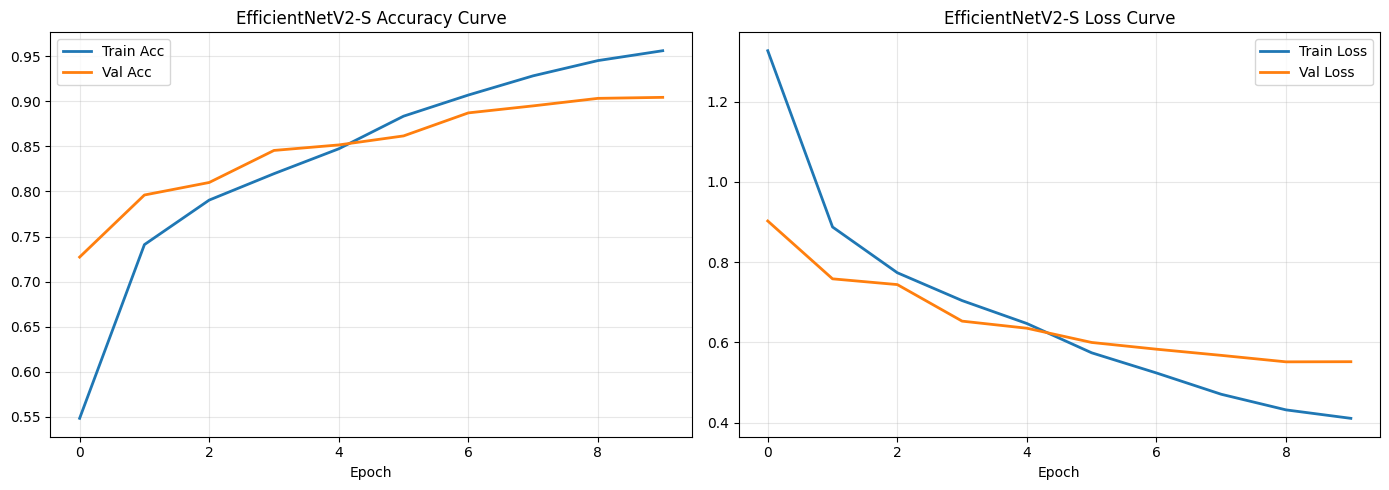

In [16]:
# ─────────────────────────────────────────────
# Classification curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cls_history["train_acc"], label="Train Acc", linewidth=2)
axes[0].plot(cls_history["val_acc"],   label="Val Acc",   linewidth=2)
axes[0].set_title("EfficientNetV2-S Accuracy Curve"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(cls_history["train_loss"], label="Train Loss", linewidth=2)
axes[1].plot(cls_history["val_loss"],   label="Val Loss",   linewidth=2)
axes[1].set_title("EfficientNetV2-S Loss Curve"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/classification_curves.png", dpi=150, bbox_inches="tight")
plt.show()




In [17]:
# ─────────────────────────────────────────────
# Feature Extractor
# Strip the classifier head → 1280-dim embedding
# EfficientNetV2-S: features → AdaptiveAvgPool2d → Flatten → [1280-d]
# We replace classifier with Identity to expose this 1280-d vector.
# ─────────────────────────────────────────────
effv2_model.load_state_dict(
    torch.load("/kaggle/working/efficientnetv2s_classifier_best.pth", map_location=device))
torch.save(effv2_model.state_dict(), "/kaggle/working/efficientnetv2s_full_best.pth")

feature_extractor = copy.deepcopy(effv2_model)
feature_extractor.classifier = nn.Identity()   # expose 1280-d pool output
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad_(False)
torch.save(feature_extractor.state_dict(), "/kaggle/working/efficientnetv2s_feature_extractor.pth")
print("Feature extractor ready (1280-d embeddings).\n")

gc.collect()
torch.cuda.empty_cache()


# ─────────────────────────────────────────────
# Feature Extraction
# Pipeline: image → UNet++ (CPU) mask → masked img
#           → EfficientNetV2-S backbone (GPU) → 1280-d vector
# ─────────────────────────────────────────────
@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    feats_list, labels_list = [], []
    for imgs, labels in tqdm(loader, leave=False, desc="  extract"):
        imgs = imgs.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            feats = model(imgs)
        feats_list.append(feats.detach().float().cpu().numpy())
        labels_list.append(labels.numpy())
    return np.concatenate(feats_list), np.concatenate(labels_list)

print("Extracting features...")
X_train, y_train = extract_features(feature_extractor, cls_train_loader)
X_val,   y_val   = extract_features(feature_extractor, cls_val_loader)
X_test,  y_test  = extract_features(feature_extractor, cls_test_loader)
print(f"  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}\n")

gc.collect()
torch.cuda.empty_cache()




Feature extractor ready (1280-d embeddings).

Extracting features...


  Train: (8400, 1280)  Val: (1800, 1280)  Test: (1800, 1280)



In [20]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

use_cuda = torch.cuda.is_available()

xgb_params = {
    "objective": "multi:softprob",
    "num_class": num_classes,
    "eval_metric": "mlogloss",
    "max_depth": 8,
    "eta": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "min_child_weight": 20,
    "tree_method": "hist",                  # always hist
    "device": "cuda" if use_cuda else "cpu",
    "seed": SEED,
    "verbosity": 1,
}

evals_result = {}

print("Training XGBoost...")
xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=350,
    evals=[(dtrain, "train"), (dval, "val")],
    evals_result=evals_result,
    early_stopping_rounds=30,
    verbose_eval=50,
)

xgb_model.save_model("/kaggle/working/xgboost_brain_multiclass.json")
with open("/kaggle/working/xgboost_brain_multiclass.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("XGBoost model saved.\n")

Training XGBoost...
[0]	train-mlogloss:2.22992	val-mlogloss:2.24859
[50]	train-mlogloss:0.21004	val-mlogloss:0.42313
[100]	train-mlogloss:0.06433	val-mlogloss:0.33525
[132]	train-mlogloss:0.04760	val-mlogloss:0.33922
XGBoost model saved.



Test Accuracy: 0.9122

Classification Report:
                  precision    recall  f1-score   support

   Control_Axial     0.9605    0.9733    0.9669       150
Control_Saggital     0.9539    0.9667    0.9603       150
          Glioma     0.9189    0.9067    0.9128       150
        MS_Axial     0.9539    0.9667    0.9603       150
     MS_Saggital     0.9603    0.9667    0.9635       150
      Meningioma     0.9320    0.9133    0.9226       150
    MildDemented     0.9161    0.8733    0.8942       150
ModerateDemented     0.9933    0.9933    0.9933       150
     NonDemented     0.7564    0.7867    0.7712       150
          Normal     0.9448    0.9133    0.9288       150
       Pituitary     0.9474    0.9600    0.9536       150
VeryMildDemented     0.7171    0.7267    0.7219       150

        accuracy                         0.9122      1800
       macro avg     0.9129    0.9122    0.9124      1800
    weighted avg     0.9129    0.9122    0.9124      1800



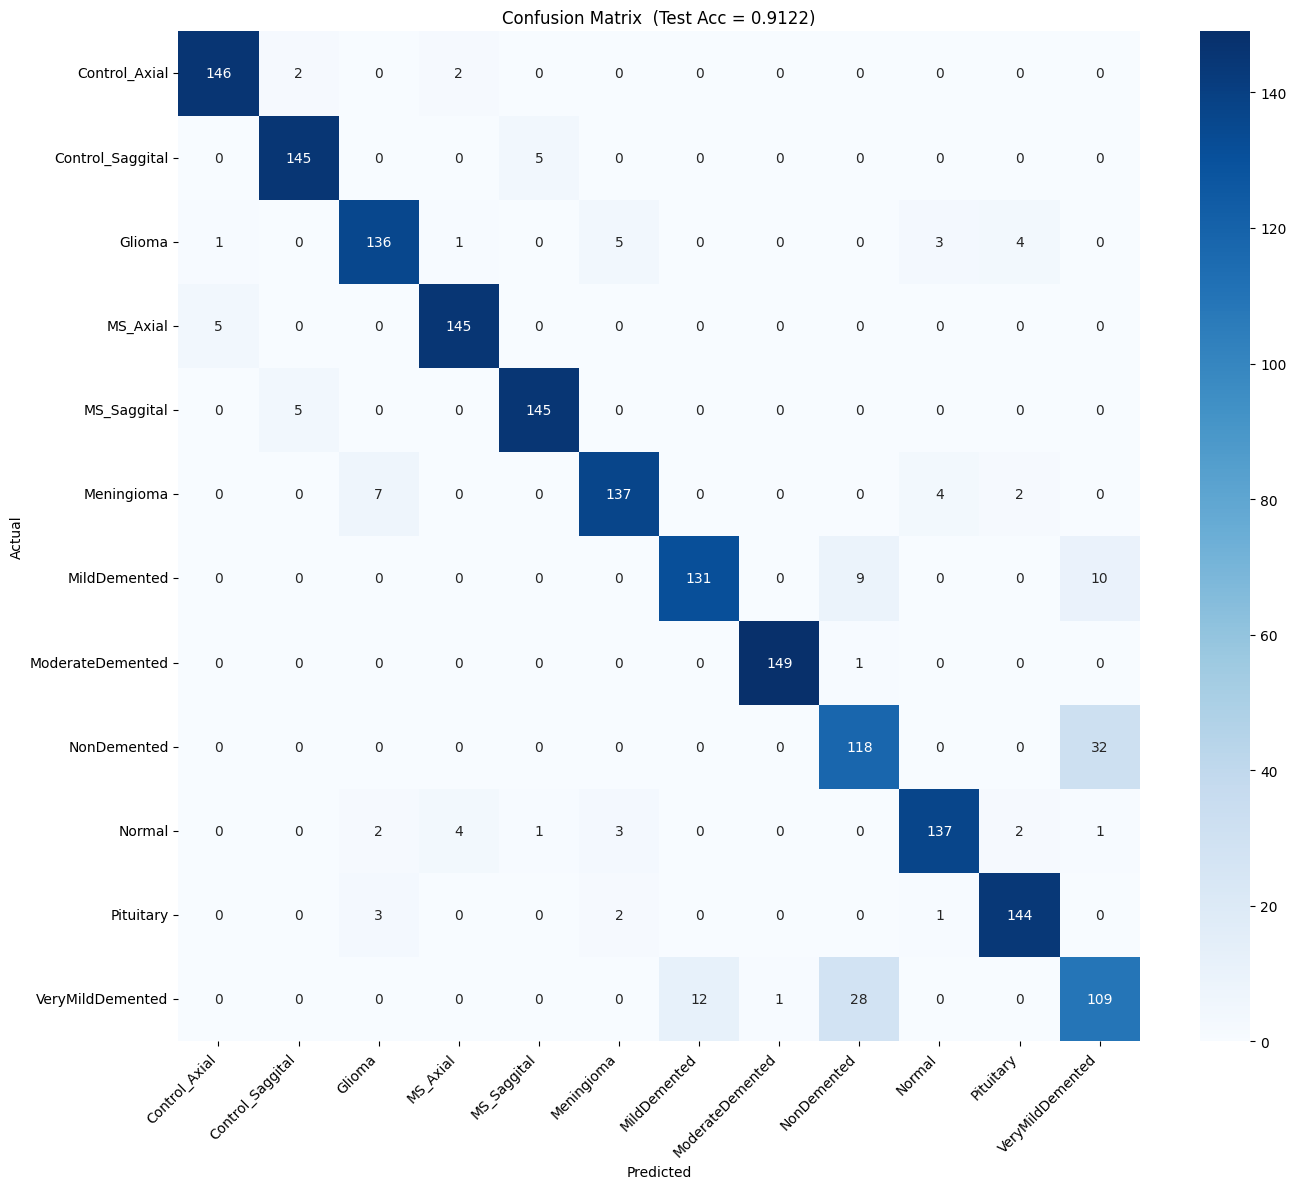

In [21]:
# ─────────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────────
y_prob   = xgb_model.predict(dtest)            # shape: (N, num_classes)
y_pred   = np.argmax(y_prob, axis=1)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[idx2label[i] for i in range(num_classes)],
    digits=4,
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[idx2label[i] for i in range(num_classes)],
    yticklabels=[idx2label[i] for i in range(num_classes)],
)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix  (Test Acc = {test_acc:.4f})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()




In [22]:
# ─────────────────────────────────────────────
# Save all artifacts
# ─────────────────────────────────────────────
artifacts = {
    "class_names"  : class_names,
    "label2idx"    : label2idx,
    "idx2label"    : idx2label,
    "seg_history"  : seg_history,
    "cls_history"  : cls_history,
    "test_accuracy": float(test_acc),
}
with open("/kaggle/working/brain_multiclass_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)
with open("/kaggle/working/label_mapping.json", "w") as f:
    json.dump(
        {"class_names": class_names,
         "label2idx"  : label2idx,
         "idx2label"  : {str(k): v for k, v in idx2label.items()}},
        f, indent=4,
    )
print("All artifacts saved.")



All artifacts saved.


In [23]:

# ─────────────────────────────────────────────
# Inference helper
# Full pipeline: image → UNet++ (CPU) → masked → EfficientNetV2-S (GPU) → XGBoost
# ─────────────────────────────────────────────
def preprocess_single_image(image_path, seg_model_cpu):
    img_u8 = read_rgb_image(image_path)
    mask   = unetpp_predict_mask(seg_model_cpu, img_u8)
    img_f  = img_u8.astype(np.float32) / 255.0 * np.expand_dims(mask, -1)
    return _normalize(torch.tensor(img_f).permute(2, 0, 1)).unsqueeze(0)  # (1,3,H,W)

@torch.no_grad()
def predict_single_image(image_path, seg_model_cpu, feat_extractor, xgb_clf, idx2label):
    x = preprocess_single_image(image_path, seg_model_cpu).to(device)
    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        feats = feat_extractor(x)
    feats    = feats.detach().float().cpu().numpy()
    dmat     = xgb.DMatrix(feats)
    probs    = xgb_clf.predict(dmat)[0]          # shape: (num_classes,)
    pred_idx = int(np.argmax(probs))
    return idx2label[pred_idx], float(np.max(probs)), probs

# Usage:
# label, conf, probs = predict_single_image(
#     test_df.loc[0, "filepath"],
#     seg_model_cpu, feature_extractor, xgb_model, idx2label
# )

In [ ]:
import cv2
import numpy as np
from PIL import Image
import torch


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, input_tensor, class_index=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_index is None:
            class_index = int(torch.argmax(output, dim=1).item())

        score = output[:, class_index]
        score.backward(retain_graph=True)

        gradients = self.gradients[0]      # [C, H, W]
        activations = self.activations[0]  # [C, H, W]

        # Global average pooling of gradients
        weights = torch.mean(gradients, dim=(1, 2))  # [C]

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam.detach().cpu().numpy()

        # Normalize
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam


def compute_brain_mask(original_image: np.ndarray) -> np.ndarray:
    """
    Compute a tight brain foreground mask using Otsu + morphology.
    Returns a float32 mask [0..1] of shape (H, W).
    """
    if original_image.dtype != np.uint8:
        original_image = original_image.astype(np.uint8)

    gray = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY)

    # Otsu threshold
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # If the mask covers more than 60% of pixels, invert (bright background)
    if np.mean(thresh > 0) > 0.6:
        thresh = cv2.bitwise_not(thresh)

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=1)

    # Keep only the largest connected component (the brain)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
    mask = np.zeros_like(gray, dtype=np.uint8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.where(labels == largest, 255, 0).astype(np.uint8)
    else:
        mask = opened

    # Slight dilation so we don't clip brain edges
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.dilate(mask, dilate_kernel, iterations=1)

    # Smooth mask edges for a natural blend
    mask = cv2.GaussianBlur(mask, (15, 15), 0)

    return mask.astype(np.float32) / 255.0


def generate_gradcam_from_tensor(
    input_tensor: torch.Tensor,
    original_image: np.ndarray,   # RGB numpy array, original unmasked image
    output_path: str,
    model,
    target_layer,
    class_index: int,
    device
):
    """
    Generate a brain-region-masked Grad-CAM overlay.
    Heatmap is constrained to the brain foreground; background stays dark/neutral.
    """
    model = model.to(device)
    model.eval()

    gradcam = GradCAM(model, target_layer)
    cam = gradcam(input_tensor, class_index=class_index)
    gradcam.remove_hooks()
    h, w = original_image.shape[:2]
    cam_resized = cv2.resize(cam, (w, h), interpolation=cv2.INTER_CUBIC)
    cam_resized = np.clip(cam_resized, 0, 1)
    brain_mask = compute_brain_mask(original_image)  # float32, [0..1], shape (H, W)
    cam_masked = cam_resized * brain_mask             # suppress background
    if cam_masked.max() > 1e-8:
        cam_masked = cam_masked / cam_masked.max()
    heatmap_uint8 = np.uint8(255 * cam_masked)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)  # BGR
    original_bgr = cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR)
    mask_3ch = np.stack([brain_mask] * 3, axis=-1)   # (H, W, 3)
    blended_brain = cv2.addWeighted(original_bgr, 0.55, heatmap_colored, 0.45, 0)
    overlay = (blended_brain * mask_3ch + original_bgr * (1.0 - mask_3ch)).astype(np.uint8)

    # ── 8. Save ──────────────────────────────────────────────────────────────
    cv2.imwrite(output_path, overlay)